<a href="https://www.kaggle.com/code/mashrur135/nb-byol?scriptVersionId=339962964" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Task B — BYOL Pretraining
### CSE 438 Part B — SSL for Semantic Segmentation


In [1]:
import os, time, json, random, copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
import torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader
from PIL import Image

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")


Using device: cuda


## Config cell

In [2]:
CONFIG = {
    "method": "BYOL",
    "backbone": "resnet50",
    "checkpoint_source": "torchvision_imagenet",
    "pretrain_epochs": 50,
    "batch_size": 4,
    "img_size": 224,
    "projection_dim": 256,
    "hidden_dim": 4096,
    "ema_decay": 0.996,       # target network EMA decay rate -- report this
    "optimizer": "Adam",
    "lr": 3e-4,
    "weight_decay": 1.5e-6,
    "seed": 42,
}

random.seed(CONFIG["seed"]); np.random.seed(CONFIG["seed"])
torch.manual_seed(CONFIG["seed"]); torch.cuda.manual_seed_all(CONFIG["seed"])

print(json.dumps(CONFIG, indent=2))


{
  "method": "BYOL",
  "backbone": "resnet50",
  "checkpoint_source": "torchvision_imagenet",
  "pretrain_epochs": 50,
  "batch_size": 4,
  "img_size": 224,
  "projection_dim": 256,
  "hidden_dim": 4096,
  "ema_decay": 0.996,
  "optimizer": "Adam",
  "lr": 0.0003,
  "weight_decay": 1.5e-06,
  "seed": 42
}


## Load the verified split artifact from the Data Prep notebook

In [3]:
TRAIN_CSV = "/kaggle/input/notebooks/mashrur135/nb-01-data-prep/artifacts/splits/train_split.csv"

train_df = pd.read_csv(TRAIN_CSV)
print(f"Unlabelled pretraining images: {len(train_df)}")


Unlabelled pretraining images: 280


## BYOL two-view augmentation


In [4]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

byol_transform = T.Compose([
    T.RandomResizedCrop(CONFIG["img_size"], scale=(0.2, 1.0)),
    T.RandomHorizontalFlip(),
    T.RandomVerticalFlip(),
    T.RandomApply([T.RandomRotation(90)], p=0.5),
    T.RandomApply([T.ColorJitter(0.4, 0.4, 0.4, 0.1)], p=0.8),
    T.RandomGrayscale(p=0.2),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

class BYOLDataset(Dataset):
    def __init__(self, df, transform):
        self.paths = df["image_path"].tolist()
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("RGB")
        return self.transform(img), self.transform(img)

train_ds = BYOLDataset(train_df, byol_transform)
train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], shuffle=True,
                           num_workers=2, drop_last=True, pin_memory=True)
print(f"Batches per epoch: {len(train_loader)}")


Batches per epoch: 70


## Online and Target networks


In [5]:
class BYOLNetwork(nn.Module):
    """Encoder + projector. Same class used for both online and target."""
    def __init__(self, projection_dim=256, hidden_dim=4096, pretrained=True):
        super().__init__()
        resnet = models.resnet50(weights="IMAGENET1K_V2" if pretrained else None)
        self.backbone = nn.Sequential(*list(resnet.children())[:-2])  # -> [B, 2048, 7, 7]
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.projector = nn.Sequential(
            nn.Linear(2048, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(inplace=True),
            nn.Linear(hidden_dim, projection_dim),
        )

    def forward(self, x):
        feature_map = self.backbone(x)                # [B, 2048, 7, 7] -- used by Task C/D
        pooled = self.pool(feature_map).flatten(1)
        z = self.projector(pooled)
        return feature_map, z


class Predictor(nn.Module):
    """Only on the ONLINE side -- this asymmetry is what prevents collapse."""
    def __init__(self, projection_dim=256, hidden_dim=4096):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(projection_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(inplace=True),
            nn.Linear(hidden_dim, projection_dim),
        )

    def forward(self, x):
        return self.net(x)


online_network = BYOLNetwork(CONFIG["projection_dim"], CONFIG["hidden_dim"]).to(DEVICE)
predictor = Predictor(CONFIG["projection_dim"], CONFIG["hidden_dim"]).to(DEVICE)

# Target starts as an exact copy of online, then NEVER receives gradients
target_network = copy.deepcopy(online_network).to(DEVICE)
for p in target_network.parameters():
    p.requires_grad = False

with torch.no_grad():
    dummy = torch.randn(2, 3, CONFIG["img_size"], CONFIG["img_size"]).to(DEVICE)
    fmap, z = online_network(dummy)
    print(f"feature_map shape: {fmap.shape}")   # expect [2, 2048, 7, 7]
    print(f"projection z shape: {z.shape}")     # expect [2, projection_dim]


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 170MB/s]


feature_map shape: torch.Size([2, 2048, 7, 7])
projection z shape: torch.Size([2, 256])


## EMA update for the target network



In [6]:
@torch.no_grad()
def update_target_network(online_net, target_net, decay):
    for online_params, target_params in zip(online_net.parameters(), target_net.parameters()):
        target_params.data = decay * target_params.data + (1 - decay) * online_params.data


## BYOL loss


In [7]:
def byol_loss(p, z):
    p = F.normalize(p, dim=1)
    z = F.normalize(z, dim=1)
    return 2 - 2 * (p * z).sum(dim=1).mean()


## Training loop (50 epochs, fixed requirement)

In [8]:
params = list(online_network.parameters()) + list(predictor.parameters())
optimizer = torch.optim.Adam(params, lr=CONFIG["lr"], weight_decay=CONFIG["weight_decay"])

loss_history, epoch_time_history = [], []

for epoch in range(CONFIG["pretrain_epochs"]):
    t0 = time.time()
    online_network.train()
    predictor.train()
    running_loss = 0.0

    for view1, view2 in train_loader:
        view1, view2 = view1.to(DEVICE), view2.to(DEVICE)

        # Online side (gradients flow)
        _, z1_online = online_network(view1)
        _, z2_online = online_network(view2)
        p1 = predictor(z1_online)
        p2 = predictor(z2_online)

        # Target side (no gradients -- stop-gradient)
        with torch.no_grad():
            _, z1_target = target_network(view1)
            _, z2_target = target_network(view2)

        # Symmetric loss: predict each view's target from the OTHER view's online prediction
        loss = byol_loss(p1, z2_target) + byol_loss(p2, z1_target)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        update_target_network(online_network, target_network, CONFIG["ema_decay"])
        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)
    epoch_time = time.time() - t0
    loss_history.append(epoch_loss)
    epoch_time_history.append(epoch_time)

    print(f"Epoch {epoch+1}/{CONFIG['pretrain_epochs']} | BYOL loss: {epoch_loss:.4f} | time: {epoch_time:.1f}s")


Epoch 1/50 | BYOL loss: 1.5343 | time: 69.7s
Epoch 2/50 | BYOL loss: 1.4423 | time: 63.8s
Epoch 3/50 | BYOL loss: 1.4376 | time: 63.1s
Epoch 4/50 | BYOL loss: 1.3427 | time: 63.4s
Epoch 5/50 | BYOL loss: 1.2003 | time: 64.2s
Epoch 6/50 | BYOL loss: 1.2514 | time: 66.4s
Epoch 7/50 | BYOL loss: 1.0782 | time: 66.8s
Epoch 8/50 | BYOL loss: 1.0475 | time: 68.6s
Epoch 9/50 | BYOL loss: 0.9420 | time: 68.1s
Epoch 10/50 | BYOL loss: 0.8329 | time: 71.1s
Epoch 11/50 | BYOL loss: 0.8350 | time: 70.0s
Epoch 12/50 | BYOL loss: 0.7509 | time: 69.4s
Epoch 13/50 | BYOL loss: 0.7759 | time: 68.5s
Epoch 14/50 | BYOL loss: 0.7770 | time: 69.3s
Epoch 15/50 | BYOL loss: 0.7439 | time: 65.2s
Epoch 16/50 | BYOL loss: 0.6711 | time: 65.8s
Epoch 17/50 | BYOL loss: 0.5837 | time: 66.5s
Epoch 18/50 | BYOL loss: 0.5449 | time: 66.3s
Epoch 19/50 | BYOL loss: 0.5438 | time: 65.7s
Epoch 20/50 | BYOL loss: 0.5844 | time: 63.9s
Epoch 21/50 | BYOL loss: 0.5193 | time: 64.6s
Epoch 22/50 | BYOL loss: 0.5142 | time: 63.

## Loss curve + per-epoch time (required for report)

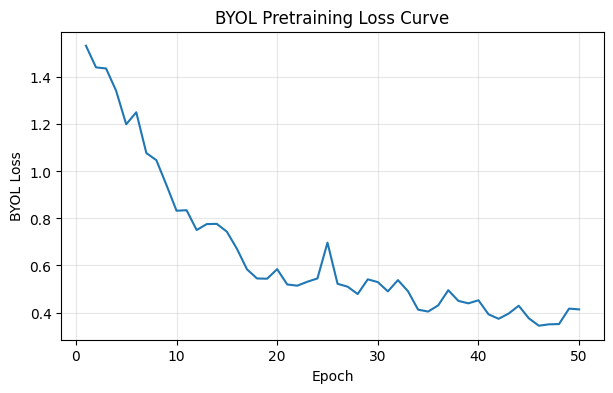

Average per-epoch time: 65.1s


In [9]:
plt.figure(figsize=(7, 4))
plt.plot(range(1, len(loss_history) + 1), loss_history)
plt.xlabel("Epoch"); plt.ylabel("BYOL Loss"); plt.title("BYOL Pretraining Loss Curve")
plt.grid(alpha=0.3)
plt.savefig("/kaggle/working/byol_pretrain_loss.png", dpi=150, bbox_inches="tight")
plt.show()

avg_epoch_time = sum(epoch_time_history) / len(epoch_time_history)
print(f"Average per-epoch time: {avg_epoch_time:.1f}s")


## Save encoder checkpoint for Task C


In [10]:
torch.save({
    "backbone_state_dict": online_network.backbone.state_dict(),
    "config": CONFIG,
    "final_loss": loss_history[-1],
    "avg_epoch_time_sec": avg_epoch_time,
}, "/kaggle/working/byol_encoder_checkpoint.pth")

print("Saved: /kaggle/working/byol_encoder_checkpoint.pth")
print("Feeds Task C: attach ASPP decoder to online_network.backbone's [2048,7,7] output.")


Saved: /kaggle/working/byol_encoder_checkpoint.pth
Feeds Task C: attach ASPP decoder to online_network.backbone's [2048,7,7] output.
